In [1]:
import os # for file operations
import matplotlib.pyplot as plt # for plotting

In [2]:
sizes_kb = [1, 2, 4, 8, 16, 32] # Cache sizes in kB
sizes_str = ["1kB", "2kB", "4kB", "8kB", "16kB", "32kB"] # Cache sizes as strings for file names

In [3]:
scenarios = { # Mapping of scenario names to their corresponding output directories and file name patterns
    "A7 - Dijkstra": ("m5out_A7", "size_"),
    "A15 - Dijkstra": ("m5out_A15", "size_"),
    "A7 - Blowfish": ("m5out_A7", "blowfish_size_"),
    "A15 - Blowfish": ("m5out_A15", "blowfish_size_"),
}

In [4]:
def get_ipc(stats_file): # Function to extract IPC from a given stats file
    if not os.path.exists(stats_file):
        return None
    
    with open(stats_file, "r") as f:
        for line in f:
            if "system.cpu.ipc" in line:
                parts = line.split()
                return float(parts[1])
    return None

In [5]:
results = {}

for label, (base_dir, prefix) in scenarios.items():        
    x_vals = []
    y_vals = []
    
    for i, size in enumerate(sizes_str):
        folder_path = os.path.join(base_dir, f"{prefix}{size}")
        stats_path = os.path.join(folder_path, "stats.txt")
        
        ipc = get_ipc(stats_path)
        
        if ipc is not None:
            x_vals.append(sizes_kb[i])
            y_vals.append(ipc)
        else:
            pass
    
    if x_vals:
        results[label] = (x_vals, y_vals)

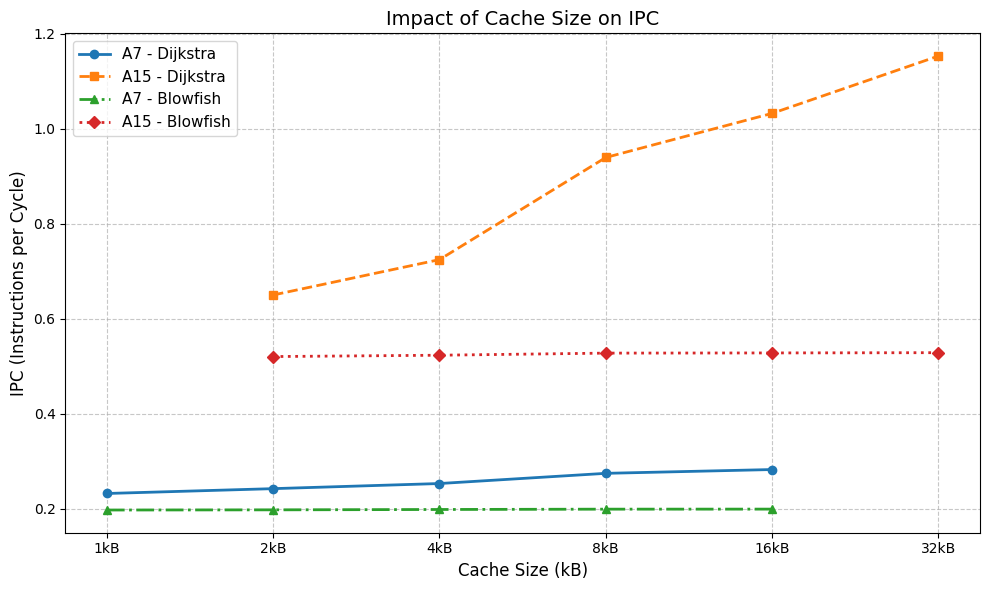

In [6]:
plt.figure(figsize=(10, 6))

markers = ['o', 's', '^', 'D']
styles = ['-', '--', '-.', ':']

for i, (label, (x, y)) in enumerate(results.items()):
    plt.plot(x, y, 
             marker=markers[i % len(markers)], 
             linestyle=styles[i % len(styles)], 
             linewidth=2, 
             label=label)

plt.title("Impact of Cache Size on IPC", fontsize=14)
plt.xlabel("Cache Size (kB)", fontsize=12)
plt.ylabel("IPC (Instructions per Cycle)", fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.xscale('log', base=2)
plt.xticks(sizes_kb, sizes_str)

plt.tight_layout()
plt.show()